In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NC.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'NC/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'AD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('MCI.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'MCI/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #44
print(count_no) #247
print(count_mci) #106

72
358
86


In [3]:
ad_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4','bl':'1'}
for i in data_ad:
    j= i[14:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    ad_array = np.array(num_list)
    ad_arrays.append(ad_array)
ad_array = np.vstack(ad_arrays)

In [4]:
normal_arrays=[]
for i in data_normal:
    j= i[14:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    normal_array = np.array(num_list)
    normal_arrays.append(normal_array)
normal_array = np.vstack(normal_arrays)

In [5]:
mci_arrays=[]
for i in data_mci:
    j= i[14:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    mci_array = np.array(num_list)
    mci_arrays.append(mci_array)
mci_array = np.vstack(mci_arrays)

In [6]:
#加权算值
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [7]:
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()
normal_labels = torch.zeros(normal_tensor.shape[0], dtype=torch.long)
mci_labels = torch.ones(mci_tensor.shape[0], dtype=torch.long)
ad_labels = torch.full((ad_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([ad_tensor, normal_tensor, mci_tensor], dim=0)
y = torch.cat([ad_labels, normal_labels, mci_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=9)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(50):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
with torch.no_grad():
    ad_tensor = model(ad_tensor)
    normal_tensor = model(normal_tensor)
    mci_tensor = model(mci_tensor)
    
ad_tensor = weighted_sum(ad_tensor)
mci_tensor = weighted_sum(mci_tensor)
normal_tensor = weighted_sum(normal_tensor)

print('AD_tensor shape:', ad_tensor.shape)
print('Normal_tensor shape:', normal_tensor.shape)
print('MCI_tensor shape:', mci_tensor.shape)

AD_tensor shape: torch.Size([72, 1])
Normal_tensor shape: torch.Size([358, 1])
MCI_tensor shape: torch.Size([86, 1])


In [8]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[3:18])
    return np.array(processed_data)

In [9]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [10]:
ad_data = preprocess_data(data_ad, replace_dict)
normal_data = preprocess_data(data_normal, replace_dict)
mci_data = preprocess_data(data_mci, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer = nn.Linear(15, 8)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(8, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('mci.EHR--->',mci_EHR.shape)

ad.EHR---> torch.Size([72, 1])
normal.EHR---> torch.Size([358, 1])
mci.EHR---> torch.Size([86, 1])


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# 先导入模型定义（你cell1里已import）
nii = CNN_3D(num_class=1)    # 输出维度根据你的网络结构和任务来设
nii = nii.to(device)

def get_nii_file_list(folder_path):
    import os
    return [os.path.join(folder_path, f) for f in os.listdir(folder_path)
            if f.endswith('.nii') or f.endswith('.nii.gz')]

# 加在Cell12前，假设你的CNN_3D模型叫 nii，且device设置好了
# --- AD ---
ad_nii_files = get_nii_file_list('AD')
dataset = NiiDataset(ad_nii_files)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output.cpu())
ad_output = torch.cat(all_outputs, dim=0)

# --- NC ---
normal_nii_files = get_nii_file_list('NC')
dataset = NiiDataset(normal_nii_files)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output.cpu())
normal_output = torch.cat(all_outputs, dim=0)

# --- MCI ---
mci_nii_files = get_nii_file_list('MCI')
dataset = NiiDataset(mci_nii_files)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output.cpu())
mci_output = torch.cat(all_outputs, dim=0)

print('ad_output shape:', ad_output.shape)
print('normal_output shape:', normal_output.shape)
print('mci_output shape:', mci_output.shape)


ad_output shape: torch.Size([72, 1])
normal_output shape: torch.Size([358, 1])
mci_output shape: torch.Size([86, 1])


In [13]:


# 获取EHR主键顺序（假设 row[1] 是nii文件名，不带扩展名）
ad_ehr_keys = [os.path.splitext(row[1])[0] for row in data_ad]
mci_ehr_keys = [os.path.splitext(row[1])[0] for row in data_mci]
normal_ehr_keys = [os.path.splitext(row[1])[0] for row in data_normal]

# NII文件主键到索引
ad_nii_files = get_nii_file_list('AD')
ad_nii_key2idx = {os.path.splitext(os.path.basename(f))[0]: i for i, f in enumerate(ad_nii_files)}
mci_nii_files = get_nii_file_list('MCI')
mci_nii_key2idx = {os.path.splitext(os.path.basename(f))[0]: i for i, f in enumerate(mci_nii_files)}
normal_nii_files = get_nii_file_list('NC')
normal_nii_key2idx = {os.path.splitext(os.path.basename(f))[0]: i for i, f in enumerate(normal_nii_files)}

# 对齐NII输出，只保留EHR有的部分（顺序与EHR一致）
ad_nii_indices = [ad_nii_key2idx[k] for k in ad_ehr_keys if k in ad_nii_key2idx]
ad_output_aligned = ad_output[ad_nii_indices]

mci_nii_indices = [mci_nii_key2idx[k] for k in mci_ehr_keys if k in mci_nii_key2idx]
mci_output_aligned = mci_output[mci_nii_indices]

normal_nii_indices = [normal_nii_key2idx[k] for k in normal_ehr_keys if k in normal_nii_key2idx]
normal_output_aligned = normal_output[normal_nii_indices]

# 检查对齐后shape
print('ad_EHR:', ad_EHR.shape, 'ad_output_aligned:', ad_output_aligned.shape)
print('mci_EHR:', mci_EHR.shape, 'mci_output_aligned:', mci_output_aligned.shape)
print('normal_EHR:', normal_EHR.shape, 'normal_output_aligned:', normal_output_aligned.shape)


ad_EHR: torch.Size([72, 1]) ad_output_aligned: torch.Size([72, 1])
mci_EHR: torch.Size([86, 1]) mci_output_aligned: torch.Size([86, 1])
normal_EHR: torch.Size([358, 1]) normal_output_aligned: torch.Size([358, 1])


In [14]:
import os

def get_nii_file_list(folder_path):
    return [os.path.join(folder_path, f) for f in os.listdir(folder_path)
            if f.endswith('.nii') or f.endswith('.nii.gz')]

batch_size = 16

# AD
ad_nii_files = get_nii_file_list('AD')
dataset = NiiDataset(ad_nii_files)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
ad_output = torch.cat(all_outputs, dim=0)
print('ad nii shape--->', ad_output.shape)

# NC
normal_nii_files = get_nii_file_list('NC')
dataset = NiiDataset(normal_nii_files)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
normal_output = torch.cat(all_outputs, dim=0)
print('normal nii shape--->', normal_output.shape)

# MCI
mci_nii_files = get_nii_file_list('MCI')
dataset = NiiDataset(mci_nii_files)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
mci_output = torch.cat(all_outputs, dim=0)
print('mci nii shape--->', mci_output.shape)


ad nii shape---> torch.Size([72, 1])
normal nii shape---> torch.Size([358, 1])
mci nii shape---> torch.Size([86, 1])


In [15]:
# 定义文件夹路径
nii_folders = {
    'ad': 'AD',
    'normal': 'NC',
    'mci': 'MCI'
}

ad_df = pd.read_csv('AD.csv')
normal_df = pd.read_csv('NC.csv')
mci_df = pd.read_csv('MCI.csv')

# 提取所有实体
entities = set()
for df in [ad_df, normal_df, mci_df]:
    for col in df.columns[8:]:
        entities.update(df[col].astype(str).unique())


entities.update(df['filename'].astype(str).unique())

entity2id = {}
with open('entity2id.txt', 'r') as f:
    for line in f:
        entity, id = line.strip().split('\t')
        entity2id[entity] = id  


entity_embeddings = torch.randn(len(entity2id), 32)  # 这里假设嵌入维度为32

# 定义TransE模型类
class TransEextract:
    def __init__(self, entity_embeddings, entity2id):
        self.entity_embeddings = entity_embeddings
        self.entity2id = entity2id
        self.id_to_index = {id: idx for idx, id in enumerate(sorted(entity2id.values()))}

    def get_entity_embedding(self, entity):
        if entity in self.entity2id:
            entity_id = self.entity2id[entity]
            entity_index = self.id_to_index[entity_id]
            return self.entity_embeddings[entity_index]
        else:
            raise ValueError(f"Entity {entity} not found in entity2id mapping")

# 初始化模型
model = TransEextract(entity_embeddings, entity2id)

# 获取嵌入向量
def get_embeddings(df, model, nii_folder):
    embeddings_list = []
    for index, row in df.iterrows():
        # 检查 .nii 文件是否存在
        nii_file = row.iloc[1]  # 假设第二列是 .nii 文件名
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            #print(f"Row {index}: .nii file {nii_file} does not exist. Skipping this row.")
            continue
        
        row_embeddings = []
        for col in df.columns[8:]:  # 从第9列开始的所有列都是实体
            entity = str(row[col])
            if entity != '0' and entity in model.entity2id:
                row_embeddings.append(model.get_entity_embedding(entity))
        
        # 将路径和文件名也作为实体
        filename = str(row['filename'])
        if filename in model.entity2id:
            row_embeddings.append(model.get_entity_embedding(filename))
        
        if row_embeddings:
            mean_embedding = torch.stack(row_embeddings).mean(dim=0)
            embeddings_list.append(mean_embedding)

    
    if not embeddings_list:
        return torch.empty((0, 32))
    
    return torch.stack(embeddings_list)

# 获取嵌入向量
ad_transe = get_embeddings(ad_df, model, nii_folders['ad'])
mci_transe = get_embeddings(mci_df, model, nii_folders['mci'])
normal_transe = get_embeddings(normal_df, model, nii_folders['normal'])

# 检查嵌入向量矩阵的大小
print(f"ad_transe shape: {ad_transe.shape}")
print(f"mci_transe shape: {mci_transe.shape}")
print(f"normal_transe shape: {normal_transe.shape}")

ad_transe shape: torch.Size([72, 32])
mci_transe shape: torch.Size([86, 32])
normal_transe shape: torch.Size([358, 32])


In [16]:

transe_embed_dim = 32
X_ad = torch.cat([ad_EHR, ad_output_aligned.cpu(), ad_tensor, ad_transe], dim=1)
X_mci = torch.cat([mci_EHR, mci_output_aligned.cpu(), mci_tensor, mci_transe], dim=1)
X_normal = torch.cat([normal_EHR, normal_output_aligned.cpu(), normal_tensor, normal_transe], dim=1)

y_ad = torch.ones(len(X_ad)) * 2
y_mci = torch.ones(len(X_mci)) * 1
y_normal = torch.ones(len(X_normal)) * 0

X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()


features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:]  

X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)


X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  # Use LongTensor for classification labels
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)


train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [17]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [18]:
embed_dim = 32
transe_embed_dim = 32
num_epochs = 200
batch_size = 32
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_decay = 1e-3

transe_model = TransEModel(num_entities=526, num_relations=3, embed_dim=200)
transe_model.load_state_dict(torch.load('transe.ckpt', map_location=torch.device('cpu')))
transe_model.eval()

model = KGMultiModalTransformer(embed_dim=embed_dim, transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/200, Train Loss: 0.9857, Train AUC: 0.5129  test Loss: 1.0117, test AUC: 0.5071


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2/200, Train Loss: 0.9710, Train AUC: 0.5284  test Loss: 0.9874, test AUC: 0.5119


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Epoch 95/200, Train Loss: 0.6650, Train AUC: 0.8986  test Loss: 0.6514, test AUC: 0.8254


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 96/200, Train Loss: 0.6804, Train AUC: 0.8874  test Loss: 0.6358, test AUC: 0.8300


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 97/200, Train Loss: 0.6544, Train AUC: 0.9052  test Loss: 0.6348, test AUC: 0.8334
Epoch 98/200, Train Loss: 0.6628, Train AUC: 0.8940  test Loss: 0.6398, test AUC: 0.8367
Epoch 99/200, Train Loss: 0.6420, Train AUC: 0.9085  test Loss: 0.6365, test AUC: 0.8368
Epoch 100/200, Train Loss: 0.6503, Train AUC: 0.8959  test Loss: 0.6338, test AUC: 0.8392
Epoch 101/200, Train Loss: 0.6420, Train AUC: 0.9037  test Loss: 0.6312, test AUC: 0.8460
Epoch 102/200, Train Loss: 0.6315, Train AUC: 0.9109  test Loss: 0.6211, test AUC: 0.8467
Epoch 103/200, Train Loss: 0.6381, Train AUC: 0.9040  test Loss: 0.6167, test AUC: 0.8468
Epoch 104/200, Train Loss: 0.6396, Train AUC: 0.9106  test Loss: 0.6078, test AUC: 0.8510
Epoch 105/200, Train Loss: 0.6293, Train AUC: 0.9072  test Loss: 0.6109, test AUC: 0.8564
Epoch 106/200, Train Loss: 0.6233, Train AUC: 0.9258  test Loss: 0.6116, test AUC: 0.8576
Epoch 107/200, Train Loss: 0.6189, Train AUC: 0.9060  test Loss: 0.5958, test AUC: 0.8568
Epoch 108/200

In [19]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.7831
Recall:    0.6437
F1 Score:  0.5112
Precision: 0.4568
AUC-ROC:   0.9100


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


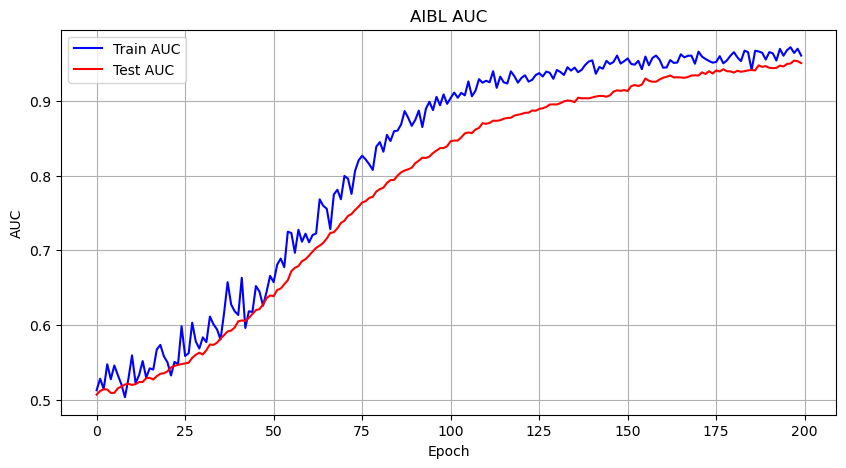

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("AIBL AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

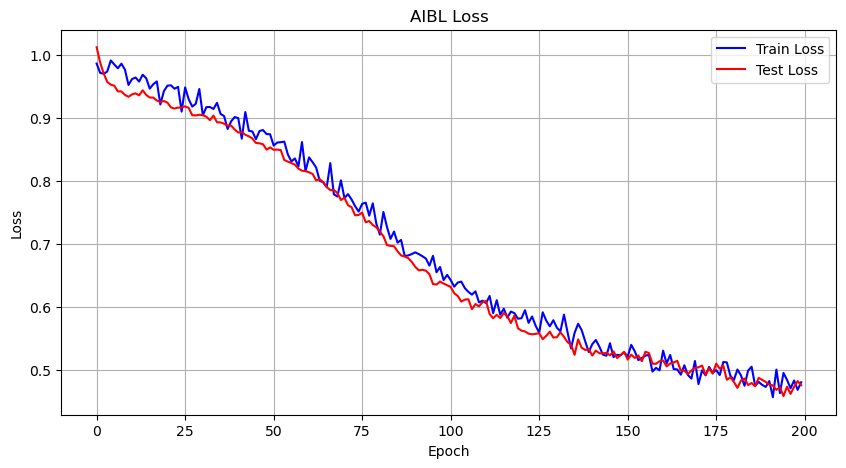

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("AIBL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()